In [4]:
!pip install scikit-learn matplotlib pandas numpy

In [7]:
# Numpy Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn datasets & model selection
from sklearn.datasets import (make_classification, make_regression,
                              load_breast_cancer, load_diabetes)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics — THE CORE OF THIS NOTEBOOK
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score,
    ConfusionMatrixDisplay
)

In [8]:
# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print("✅ All libraries loaded successfully!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")

✅ All libraries loaded successfully!
NumPy: 2.0.2 | Pandas: 2.2.2


In [9]:
# Dataset preparation

# Classification: Breast Cancer Dataset
cancer = load_breast_cancer()

X_clf, y_clf = cancer.data, cancer.target  # 0=malignant, 1=benign

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size=0.2, random_state=42
)

# Feature scaling - important for Logistic Regression and SVM
scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

# Diabetes dataset
diabetes = load_diabetes()

X_reg, y_reg = diabetes.data, diabetes.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.2, random_state=42
)

scaler_r = StandardScaler()

X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

# ---Quick data summary---
print("CLASSIFICATION DATASET (Breast Cancer)")
print(f"   Train: {X_train_c.shape} | Test: {X_test_c.shape}")
print(f"   Class balance — Malignant: {(y_clf==0).sum()} | Benign: {(y_clf==1).sum()}\n")

print("REGRESSION DATASET (Diabetes)")
print(f"   Train: {X_train_r.shape} | Test: {X_test_r.shape}")
print(f"   Target range: [{y_reg.min():.0f}, {y_reg.max():.0f}]")

CLASSIFICATION DATASET (Breast Cancer)
   Train: (455, 30) | Test: (114, 30)
   Class balance — Malignant: 212 | Benign: 357

REGRESSION DATASET (Diabetes)
   Train: (353, 10) | Test: (89, 10)
   Target range: [25, 346]


Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Class imbalance ratio: 0.59


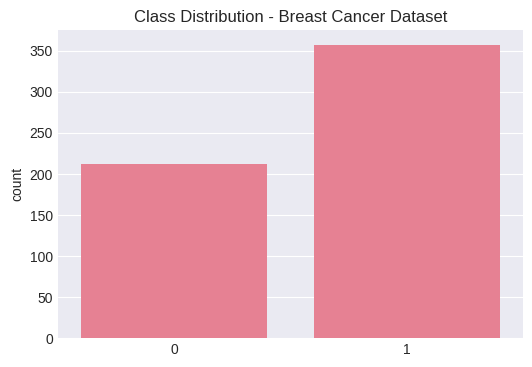

In [12]:
# STUDENT TASKS:
# 1. Print the feature names of breast cancer dataset
# 2. Calculate and print class imbalance ratio (malignant/benign)
# 3. Plot a bar chart showing class distribution


# TODO: Print first 5 feature names
print("Feature names:", cancer.feature_names[:5])

# TODO: Calculate imbalance ratio
imbalance_ratio = (y_clf == 0).sum() / (y_clf == 1).sum()

print(f"Class imbalance ratio: {imbalance_ratio:.2f}")

# TODO: Plot class distribution
plt.figure(figsize=(6, 4))

sns.countplot(x=y_clf)

plt.title("Class Distribution - Breast Cancer Dataset")
plt.show()

Logistic Regression: Accuracy = 0.9737
Random Forest: Accuracy = 0.9649
Gradient Boosting: Accuracy = 0.9561


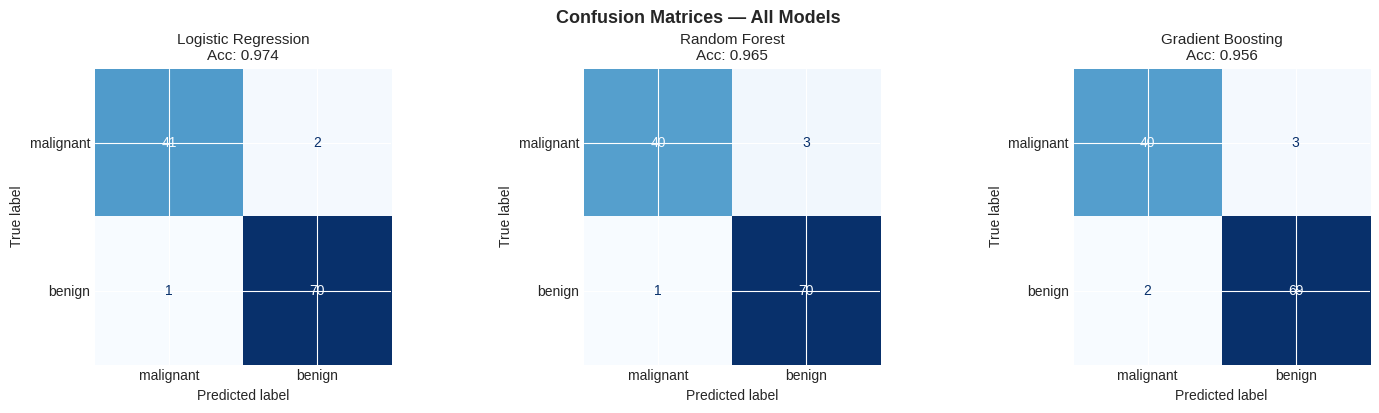

In [13]:
# Accuracy and Confusion Matrix

# Train three classifiers for comparison
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}


results = {}

for name, model in models.items():

    model.fit(X_train_c, y_train_c)

    y_pred = model.predict(X_test_c)

    y_proba = model.predict_proba(X_test_c)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test_c, y_pred),
        'cm': confusion_matrix(y_test_c, y_pred)
    }

    print(f"{name}: Accuracy = {results[name]['accuracy']:.4f}")


# ---- Visualise confusion matrices side by side ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=cancer.target_names
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f"{name}\nAcc: {res['accuracy']:.3f}",
        fontsize=11
    )

plt.tight_layout()

plt.suptitle(
    "Confusion Matrices — All Models",
    y=1.02,
    fontsize=13,
    fontweight='bold'
)

plt.show()

In [14]:
# ---- 🧠 STUDENT TASK 2 : Confusion Matrix Deep Dive ------------------------

# Instructions:
# 1. Pick the Logistic Regression model's confusion matrix
# 2. Extract TP, FP, TN, FN values manually
# 3. Calculate accuracy from scratch (without sklearn) and verify it matches

# Recall:
# sklearn's confusion_matrix returns:
# [[TN, FP],
#  [FN, TP]]


# Get Logistic Regression confusion matrix
cm = results['Logistic Regression']['cm']

print("Confusion Matrix:\n")
print(cm)


# Extract values manually
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]


print("\nExtracted Values:")
print(f"True Negatives  (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives  (TP): {TP}")


# Calculate accuracy manually
manual_accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"\nManual Accuracy: {manual_accuracy:.4f}")


# Compare with sklearn accuracy
sklearn_accuracy = results['Logistic Regression']['accuracy']

print(f"Sklearn Accuracy: {sklearn_accuracy:.4f}")


# Verification
if abs(manual_accuracy - sklearn_accuracy) < 1e-10:
    print("\n✅ Verification Successful: Both accuracies match!")
else:
    print("\n❌ Verification Failed: Values do not match.")

Confusion Matrix:

[[41  2]
 [ 1 70]]

Extracted Values:
True Negatives  (TN): 41
False Positives (FP): 2
False Negatives (FN): 1
True Positives  (TP): 70

Manual Accuracy: 0.9737
Sklearn Accuracy: 0.9737

✅ Verification Successful: Both accuracies match!
